In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import copy
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm import tqdm

from torchvision import models, transforms
from torchvision.models import EfficientNet_B0_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from google.colab import drive

drive.mount("/content/drive")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cuda
NVIDIA L4


In [2]:
SPLIT_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/splits")

train_df = pd.read_csv(SPLIT_DIR / "train_split.csv")
val_df = pd.read_csv(SPLIT_DIR / "val_split.csv")
test_df = pd.read_csv(SPLIT_DIR / "test_split.csv")

print(train_df.head())
print("\nOriginal training distribution:")
print(train_df["label"].value_counts())

        isic_id   lesion_id                 diagnosis_3  binary_label  label  \
0  ISIC_0024307  IL_6125741                       Nevus  Non-Melanoma      0   
1  ISIC_0024308  IL_3692653                       Nevus  Non-Melanoma      0   
2  ISIC_0024309  IL_0959663                       Nevus  Non-Melanoma      0   
3  ISIC_0024310  IL_8194852               Melanoma, NOS      Melanoma      1   
4  ISIC_0024312  IL_3471258  Pigmented benign keratosis  Non-Melanoma      0   

                                          image_path  
0  /content/drive/MyDrive/bachelor_thesis_data/HA...  
1  /content/drive/MyDrive/bachelor_thesis_data/HA...  
2  /content/drive/MyDrive/bachelor_thesis_data/HA...  
3  /content/drive/MyDrive/bachelor_thesis_data/HA...  
4  /content/drive/MyDrive/bachelor_thesis_data/HA...  

Original training distribution:
label
0    7261
1     943
Name: count, dtype: int64


In [3]:
!mkdir -p /content/HAM10000_images
!rsync -ah --info=progress2 /content/drive/MyDrive/bachelor_thesis_data/HAM10000_ISIC/images/ /content/HAM10000_images/

              0   0%    0.00kB/s    0:00:00 (xfr#0, to-chk=0/11722)


In [4]:
import os
import numpy as np
import random

SEED = 42

def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Improves reproducibility while warning instead of crashing
    # if an operation has no deterministic implementation.
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)

print(f"Random seed: {SEED}")

Random seed: 42


In [5]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

generator = torch.Generator()
generator.manual_seed(SEED)

In [6]:
old_path = "/content/drive/MyDrive/bachelor_thesis_data/HAM10000_ISIC/images"
new_path = "/content/HAM10000_images"

train_df["image_path"] = train_df["image_path"].str.replace(old_path, new_path, regex=False)
val_df["image_path"] = val_df["image_path"].str.replace(old_path, new_path, regex=False)
test_df["image_path"] = test_df["image_path"].str.replace(old_path, new_path, regex=False)

print(train_df["image_path"].iloc[0])
print("First train image exists:", Path(train_df["image_path"].iloc[0]).exists())

train_exists = train_df["image_path"].apply(lambda p: Path(p).exists())
val_exists = val_df["image_path"].apply(lambda p: Path(p).exists())
test_exists = test_df["image_path"].apply(lambda p: Path(p).exists())

print("Missing train images:", (~train_exists).sum())
print("Missing validation images:", (~val_exists).sum())
print("Missing test images:", (~test_exists).sum())

/content/HAM10000_images/ISIC_0024307.jpg
First train image exists: True
Missing train images: 0
Missing validation images: 0
Missing test images: 0


In [7]:
# Separate classes
mel_df = train_df[train_df["label"] == 1].copy()
non_mel_df = train_df[train_df["label"] == 0].copy()

# Calculate how many melanoma samples are needed to balance the training set
num_to_generate = len(non_mel_df) - len(mel_df)

print("Original training distribution:")
print(train_df["label"].value_counts())

print("\nNeed to create:", num_to_generate, "augmented melanoma samples")

# Sample melanoma rows with replacement
aug_mel_df = mel_df.sample(
    n=num_to_generate,
    replace=True,
    random_state=SEED
).copy()

# Mark original and augmented rows
train_df["is_augmented"] = False
aug_mel_df["is_augmented"] = True

# Combine original training set + duplicated melanoma rows
train_aug_df = pd.concat([train_df, aug_mel_df], ignore_index=True)

print("\nNew training distribution:")
print(train_aug_df["label"].value_counts())

print("\nAugmentation flag distribution:")
print(train_aug_df["is_augmented"].value_counts())

Original training distribution:
label
0    7261
1     943
Name: count, dtype: int64

Need to create: 6318 augmented melanoma samples

New training distribution:
label
0    7261
1    7261
Name: count, dtype: int64

Augmentation flag distribution:
is_augmented
False    8204
True     6318
Name: count, dtype: int64


In [8]:
base_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

traditional_aug_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
class MelanomaDataset(Dataset):
    def __init__(self, dataframe, base_transform=None, aug_transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.base_transform = base_transform
        self.aug_transform = aug_transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = row["image_path"]
        label = row["label"]

        image = Image.open(image_path).convert("RGB")

        # True only for duplicated melanoma rows in train_aug_df
        is_augmented = row.get("is_augmented", False)

        if is_augmented and self.aug_transform is not None:
            image = self.aug_transform(image)
        elif self.base_transform is not None:
            image = self.base_transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label

In [12]:
BATCH_SIZE = 32

train_dataset = MelanomaDataset(
    dataframe=train_aug_df,
    base_transform=base_train_transform,
    aug_transform=traditional_aug_transform
)

val_dataset = MelanomaDataset(
    dataframe=val_df,
    base_transform=eval_transform,
    aug_transform=None
)

test_dataset = MelanomaDataset(
    dataframe=test_df,
    base_transform=eval_transform,
    aug_transform=None
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker
)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 14522
Validation dataset size: 1742
Test dataset size: 1774


In [13]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)

            running_loss += loss.item() * images.size(0)

            all_labels.extend(labels.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    epoch_loss = running_loss / len(dataloader.dataset)

    return epoch_loss, all_labels, all_probs


def calculate_metrics(labels, probs, threshold=0.5):
    preds = [1 if p >= threshold else 0 for p in probs]

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs),
        "confusion_matrix": confusion_matrix(labels, preds)
    }

In [14]:
# Reset all randomness immediately before the official training run
set_seed(SEED)
generator.manual_seed(SEED)

# Create the model only once
weights = EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

set_seed(SEED)
generator.manual_seed(SEED)

EPOCHS = 20

history = []
best_val_f1 = -1.0
best_model_state = None
best_epoch = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_labels, val_probs = evaluate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    val_metrics = calculate_metrics(
        labels=val_labels,
        probs=val_probs,
        threshold=0.5
    )

    epoch_results = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "accuracy": val_metrics["accuracy"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
        "f1": val_metrics["f1"],
        "roc_auc": val_metrics["roc_auc"]
    }

    history.append(epoch_results)

    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss: {val_loss:.4f}")
    print(f"Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Precision: {val_metrics['precision']:.4f}")
    print(f"Recall: {val_metrics['recall']:.4f}")
    print(f"F1-score: {val_metrics['f1']:.4f}")
    print(f"ROC-AUC: {val_metrics['roc_auc']:.4f}")

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        print("New best model saved.")

history_df = pd.DataFrame(history)

model.load_state_dict(best_model_state)

print("\nTraining finished.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation F1-score: {best_val_f1:.4f}")


Epoch 1/20


100%|██████████| 55/55 [00:04<00:00, 11.81it/s]


Train loss: 0.1948
Val loss: 0.2286
Accuracy: 0.9018
Precision: 0.5724
Recall: 0.4508
F1-score: 0.5043
ROC-AUC: 0.9071
New best model saved.

Epoch 2/20


100%|██████████| 55/55 [00:04<00:00, 12.17it/s]


Train loss: 0.1074
Val loss: 0.2129
Accuracy: 0.9168
Precision: 0.7034
Recall: 0.4301
F1-score: 0.5338
ROC-AUC: 0.9202
New best model saved.

Epoch 3/20


...

Train loss: 0.0099
Val loss: 0.4463
Accuracy: 0.9059
Precision: 0.5986
Recall: 0.4560
F1-score: 0.5176
ROC-AUC: 0.8992

Epoch 19/20


100%|██████████| 55/55 [00:04<00:00, 11.67it/s]


Train loss: 0.0047
Val loss: 0.5329
Accuracy: 0.8972
Precision: 0.5372
Recall: 0.5233
F1-score: 0.5302
ROC-AUC: 0.8871

Epoch 20/20


100%|██████████| 55/55 [00:04<00:00, 12.05it/s]


Train loss: 0.0082
Val loss: 0.5172
Accuracy: 0.8938
Precision: 0.5198
Recall: 0.5440
F1-score: 0.5316
ROC-AUC: 0.8865

Training finished.
Best epoch: 7
Best validation F1-score: 0.6123


In [15]:
CHECKPOINT_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/checkpoints")
RESULTS_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/results/tables")

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

torch.save(
    best_model_state,
    CHECKPOINT_DIR / "traditional_aug_seed42_best.pth"
)

history_df.to_csv(
    RESULTS_DIR / "traditional_aug_seed42_training_history.csv",
    index=False
)

print("Saved:")
print(CHECKPOINT_DIR / "traditional_aug_seed42_best.pth")
print(RESULTS_DIR / "traditional_aug_seed42_training_history.csv")

Saved:
/content/drive/MyDrive/bachelor_thesis_data/checkpoints/traditional_aug_seed42_best.pth
/content/drive/MyDrive/bachelor_thesis_data/results/tables/traditional_aug_seed42_training_history.csv


In [16]:


best_val_loss, best_val_labels, best_val_probs = evaluate(
    model=model,
    dataloader=val_loader,
    criterion=criterion,
    device=device
)

best_val_metrics = calculate_metrics(
    labels=best_val_labels,
    probs=best_val_probs,
    threshold=0.5
)

print("\nBest model validation results:")
print(f"Val loss: {best_val_loss:.4f}")
print(f"Accuracy: {best_val_metrics['accuracy']:.4f}")
print(f"Precision: {best_val_metrics['precision']:.4f}")
print(f"Recall: {best_val_metrics['recall']:.4f}")
print(f"F1-score: {best_val_metrics['f1']:.4f}")
print(f"ROC-AUC: {best_val_metrics['roc_auc']:.4f}")
print("Confusion matrix:")
print(best_val_metrics["confusion_matrix"])

100%|██████████| 55/55 [00:04<00:00, 11.77it/s]


Best model validation results:
Val loss: 0.3518
Accuracy: 0.9099
Precision: 0.5849
Recall: 0.6425
F1-score: 0.6123
ROC-AUC: 0.9202
Confusion matrix:
[[1461   88]
 [  69  124]]


In [18]:
# ----------------------------
# Final test evaluation using the best model
# ----------------------------

test_loss, test_labels, test_probs = evaluate(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

test_metrics = calculate_metrics(
    labels=test_labels,
    probs=test_probs,
    threshold=0.5
)

# Extract confusion matrix returned by calculate_metrics()
test_cm = test_metrics["confusion_matrix"]

test_results = {
    "experiment": "E2_traditional_augmentation",
    "model": "EfficientNet-B0",
    "seed": SEED,
    "threshold": 0.5,
    "best_epoch": best_epoch,
    "test_loss": test_loss,
    "accuracy": test_metrics["accuracy"],
    "precision": test_metrics["precision"],
    "recall": test_metrics["recall"],
    "f1": test_metrics["f1"],
    "roc_auc": test_metrics["roc_auc"],
    "true_negatives": int(test_cm[0, 0]),
    "false_positives": int(test_cm[0, 1]),
    "false_negatives": int(test_cm[1, 0]),
    "true_positives": int(test_cm[1, 1])
}

test_results_df = pd.DataFrame([test_results])

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

test_results_df.to_csv(
    RESULTS_DIR / "traditional_aug_seed42_test_results.csv",
    index=False
)

print("\nBest model test results:")
print(f"Test loss: {test_loss:.4f}")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall: {test_metrics['recall']:.4f}")
print(f"F1-score: {test_metrics['f1']:.4f}")
print(f"ROC-AUC: {test_metrics['roc_auc']:.4f}")
print("Confusion matrix:")
print(test_cm)

print("\nSaved:")
print(RESULTS_DIR / "traditional_aug_seed42_test_results.csv")

test_results_df

100%|██████████| 56/56 [00:04<00:00, 12.04it/s]


Best model test results:
Test loss: 0.3437
Accuracy: 0.9076
Precision: 0.5134
Recall: 0.5680
F1-score: 0.5393
ROC-AUC: 0.8986
Confusion matrix:
[[1514   91]
 [  73   96]]

Saved:
/content/drive/MyDrive/bachelor_thesis_data/results/tables/traditional_aug_seed42_test_results.csv


,experiment,model,seed,threshold,best_epoch,test_loss,accuracy,precision,recall,f1,roc_auc,true_negatives,false_positives,false_negatives,true_positives
0,E2_traditional_augmentation,EfficientNet-B0,42,0.5,7,0.34373,0.907554,0.513369,0.568047,0.539326,0.898645,1514,91,73,96


,epoch,train_loss,val_loss,accuracy,precision,recall,f1,roc_auc
0,1,0.194820,0.228571,0.901837,0.572368,0.450777,0.504348,0.907107
1,2,0.107389,0.212918,0.916762,0.703390,0.430052,0.533762,0.920179
2,3,0.067328,0.230892,0.914466,0.650685,0.492228,0.560472,0.917747
3,4,0.047346,0.321582,0.902985,0.572289,0.492228,0.529248,0.892720
4,5,0.030205,0.305922,0.917910,0.681159,0.487047,0.567976,0.891844
5,6,0.025787,0.292625,0.911596,0.651163,0.435233,0.521739,0.912743
6,7,0.021152,0.351775,0.909874,0.584906,0.642487,0.612346,0.920152
7,8,0.017511,0.385676,0.907003,0.585635,0.549223,0.566845,0.899927
8,9,0.015422,0.338986,0.909300,0.615894,0.481865,0.540698,0.906997
9,10,0.014327,0.375256,0.912170,0.635135,0.487047,0.551320,0.903290


Lowest validation loss:
Epoch 2, val_loss = 0.2129

Highest validation F1-score:
Epoch 7, F1 = 0.6123


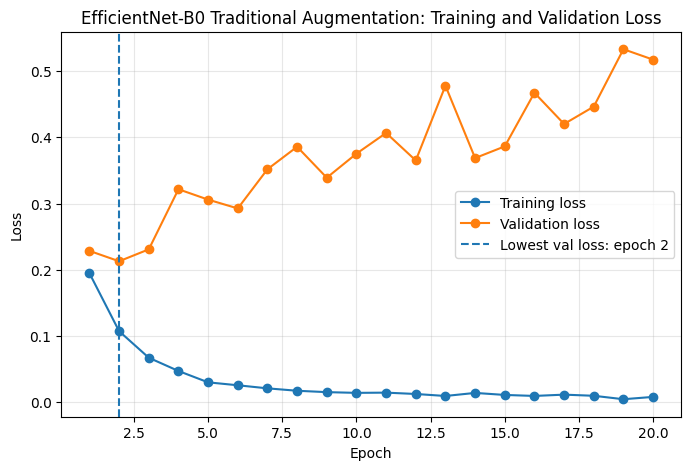

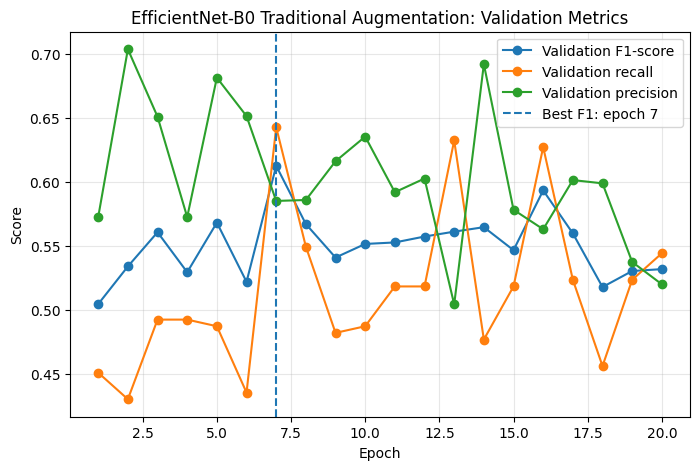

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load saved training history
HISTORY_PATH = "/content/drive/MyDrive/bachelor_thesis_data/results/tables/traditional_aug_seed42_training_history.csv"

history_df = pd.read_csv(HISTORY_PATH)

display(history_df)

# Find best epoch according to validation loss
best_val_loss_idx = history_df["val_loss"].idxmin()
best_val_loss_epoch = int(history_df.loc[best_val_loss_idx, "epoch"])
best_val_loss = history_df.loc[best_val_loss_idx, "val_loss"]

# Find best epoch according to validation F1-score
best_f1_idx = history_df["f1"].idxmax()
best_f1_epoch = int(history_df.loc[best_f1_idx, "epoch"])
best_f1 = history_df.loc[best_f1_idx, "f1"]

print("Lowest validation loss:")
print(f"Epoch {best_val_loss_epoch}, val_loss = {best_val_loss:.4f}")

print("\nHighest validation F1-score:")
print(f"Epoch {best_f1_epoch}, F1 = {best_f1:.4f}")

# Create figure directory
FIGURE_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/results/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Training loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")

plt.axvline(
    best_val_loss_epoch,
    linestyle="--",
    label=f"Lowest val loss: epoch {best_val_loss_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 Traditional Augmentation: Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(
    FIGURE_DIR / "traditional_aug_seed42_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Plot validation metrics
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["f1"], marker="o", label="Validation F1-score")
plt.plot(history_df["epoch"], history_df["recall"], marker="o", label="Validation recall")
plt.plot(history_df["epoch"], history_df["precision"], marker="o", label="Validation precision")

plt.axvline(
    best_f1_epoch,
    linestyle="--",
    label=f"Best F1: epoch {best_f1_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("EfficientNet-B0 Traditional Augmentation: Validation Metrics")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig(
    FIGURE_DIR / "traditional_aug_seed42_validation_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

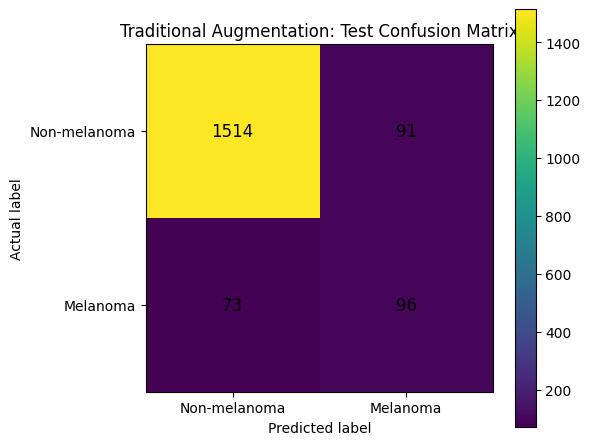

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Baseline test confusion matrix
# Rows = actual labels, columns = predicted labels
cm = np.asarray(test_metrics["confusion_matrix"])

class_names = ["Non-melanoma", "Melanoma"]

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

ax.set_title("Traditional Augmentation: Test Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=12
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()

FIGURE_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/results/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    FIGURE_DIR / "traditional_aug_seed42_test_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()